In [2]:
from pathlib import Path

BDD_ROOT = Path.home() / "Downloads" / "archive (1)" / "bdd100k"

print("BDD root:")
print(BDD_ROOT)
print()

print("Exists:", BDD_ROOT.exists())
print()

TRAIN_LABELS = BDD_ROOT / "labels" / "train"

print("Train labels:")
print(TRAIN_LABELS)
print()

print("Exists:", TRAIN_LABELS.exists())
print()

if TRAIN_LABELS.exists():
    files = list(TRAIN_LABELS.iterdir())

    print("Total files:", len(files))
    print()

    print("First 10 files:")
    for f in files[:10]:
        print(f"NAME:", f.name)
        print("SUFFIX:", repr(f.suffix))
        print("TYPE:", "file" if f.is_file() else "directory")
        print()

BDD root:
C:\Users\User\Downloads\archive (1)\bdd100k

Exists: True

Train labels:
C:\Users\User\Downloads\archive (1)\bdd100k\labels\train

Exists: True

Total files: 70000

First 10 files:
NAME: 0000f77c-6257be58.json
SUFFIX: '.json'
TYPE: file

NAME: 0000f77c-62c2a288.json
SUFFIX: '.json'
TYPE: file

NAME: 0000f77c-cb820c98.json
SUFFIX: '.json'
TYPE: file

NAME: 0001542f-5ce3cf52.json
SUFFIX: '.json'
TYPE: file

NAME: 0001542f-7c670be8.json
SUFFIX: '.json'
TYPE: file

NAME: 0001542f-ec815219.json
SUFFIX: '.json'
TYPE: file

NAME: 0004974f-05e1c285.json
SUFFIX: '.json'
TYPE: file

NAME: 00054602-3bf57337.json
SUFFIX: '.json'
TYPE: file

NAME: 00067cfb-5443fe39.json
SUFFIX: '.json'
TYPE: file

NAME: 00067cfb-5adfaaa7.json
SUFFIX: '.json'
TYPE: file



In [3]:
from pathlib import Path
import json

BDD_ROOT = Path.home() / "Downloads" / "archive (1)" / "bdd100k"

json_file = BDD_ROOT / "labels" / "train" / "0000f77c-6257be58.json"

print("File exists:", json_file.exists())
print("File:", json_file)
print()

with open(json_file, "r", encoding="utf-8") as f:
    data = json.load(f)

print("JSON type:", type(data))

if isinstance(data, dict):
    print("\nTop-level keys:")
    for key in data.keys():
        print(" -", key)

print("\nJSON content:")
print(json.dumps(data, indent=2)[:10000])

File exists: True
File: C:\Users\User\Downloads\archive (1)\bdd100k\labels\train\0000f77c-6257be58.json

JSON type: <class 'dict'>

Top-level keys:
 - name
 - frames
 - attributes

JSON content:
{
  "name": "0000f77c-6257be58",
  "frames": [
    {
      "timestamp": 10000,
      "objects": [
        {
          "category": "traffic light",
          "id": 0,
          "attributes": {
            "occluded": false,
            "truncated": false,
            "trafficLightColor": "green"
          },
          "box2d": {
            "x1": 1125.902264,
            "y1": 133.184488,
            "x2": 1156.978645,
            "y2": 210.875445
          }
        },
        {
          "category": "traffic light",
          "id": 1,
          "attributes": {
            "occluded": false,
            "truncated": false,
            "trafficLightColor": "green"
          },
          "box2d": {
            "x1": 1156.978645,
            "y1": 136.637417,
            "x2": 1191.50796,
        

In [8]:
from pathlib import Path
import json
import shutil
import csv
from tqdm import tqdm

# ============================================================
# BDD100K ORIGINAL → YOLO FORMAT CONVERTER
# ============================================================

# ------------------------------------------------------------
# 1. PATHS
# ------------------------------------------------------------

BDD_ROOT = Path(r"E:\ML_Project\archive (1)\bdd100k")

OUTPUT_ROOT = Path(r"E:\ML_Project\datasets\bdd100k_original_yolo")

print("Original BDD100K:")
print(BDD_ROOT)

print("\nOutput dataset:")
print(OUTPUT_ROOT)


# ------------------------------------------------------------
# 2. CLASS MAPPING
# ------------------------------------------------------------

CLASS_NAMES = [
    "bike",
    "bus",
    "car",
    "motor",
    "person",
    "rider",
    "traffic light",
    "traffic sign",
    "train",
    "truck"
]

CLASS_TO_ID = {
    name: idx
    for idx, name in enumerate(CLASS_NAMES)
}

print("\nClasses:")
for idx, name in enumerate(CLASS_NAMES):
    print(f"{idx}: {name}")


# ------------------------------------------------------------
# 3. IMAGE SIZE
# ------------------------------------------------------------

IMAGE_WIDTH = 1280
IMAGE_HEIGHT = 720


# ------------------------------------------------------------
# 4. DATASET SPLITS
# ------------------------------------------------------------

SPLITS = {
    "train": "train",
    "val": "valid",
    "test": "test"
}


# ------------------------------------------------------------
# 5. CREATE OUTPUT DIRECTORIES
# ------------------------------------------------------------

for original_split, output_split in SPLITS.items():

    (OUTPUT_ROOT / output_split / "images").mkdir(
        parents=True,
        exist_ok=True
    )

    (OUTPUT_ROOT / output_split / "labels").mkdir(
        parents=True,
        exist_ok=True
    )


# ------------------------------------------------------------
# 6. CONVERSION FUNCTION
# ------------------------------------------------------------

def convert_box_to_yolo(box):
    """
    Convert BDD100K pixel coordinates:

        x1, y1, x2, y2

    into YOLO format:

        class_id x_center y_center width height

    normalized to [0, 1].
    """

    x1 = float(box["x1"])
    y1 = float(box["y1"])
    x2 = float(box["x2"])
    y2 = float(box["y2"])

    # Clamp coordinates to image boundaries
    x1 = max(0.0, min(x1, IMAGE_WIDTH))
    x2 = max(0.0, min(x2, IMAGE_WIDTH))

    y1 = max(0.0, min(y1, IMAGE_HEIGHT))
    y2 = max(0.0, min(y2, IMAGE_HEIGHT))

    # Width and height
    box_width = x2 - x1
    box_height = y2 - y1

    # Ignore invalid boxes
    if box_width <= 0 or box_height <= 0:
        return None

    # Center
    x_center = (x1 + x2) / 2.0
    y_center = (y1 + y2) / 2.0

    # Normalize
    x_center /= IMAGE_WIDTH
    y_center /= IMAGE_HEIGHT
    box_width /= IMAGE_WIDTH
    box_height /= IMAGE_HEIGHT

    return (
        x_center,
        y_center,
        box_width,
        box_height
    )


# ------------------------------------------------------------
# 7. PROCESS DATASET
# ------------------------------------------------------------

total_images = 0
total_objects = 0
skipped_objects = 0
missing_images = 0

weather_records = []


for original_split, output_split in SPLITS.items():

    print("\n" + "=" * 70)
    print(f"PROCESSING: {original_split.upper()}")
    print("=" * 70)

    label_dir = BDD_ROOT / "labels" / original_split

    image_dir = BDD_ROOT / "images" / "100k" / original_split

    output_image_dir = OUTPUT_ROOT / output_split / "images"
    output_label_dir = OUTPUT_ROOT / output_split / "labels"

    json_files = sorted(label_dir.glob("*.json"))

    print("JSON annotations:", len(json_files))

    split_images = 0
    split_objects = 0

    for json_file in tqdm(
        json_files,
        desc=f"Converting {original_split}"
    ):

        # ----------------------------------------------------
        # Read JSON
        # ----------------------------------------------------

        with open(json_file, "r", encoding="utf-8") as f:
            data = json.load(f)

        image_name = data["name"]

        # BDD100K images are JPG
        image_file = image_dir / f"{image_name}.jpg"

        if not image_file.exists():

            # Try JPEG just in case
            image_file = image_dir / f"{image_name}.jpeg"

        if not image_file.exists():

            missing_images += 1
            continue

        # ----------------------------------------------------
        # Copy image
        # ----------------------------------------------------

        output_image = output_image_dir / image_file.name

        if not output_image.exists():

            shutil.copy2(
                image_file,
                output_image
            )

        # ----------------------------------------------------
        # Extract objects
        # ----------------------------------------------------

        yolo_lines = []

        frames = data.get("frames", [])

        for frame in frames:

            objects = frame.get("objects", [])

            for obj in objects:

                category = obj.get("category")

                # Ignore non-target categories
                if category not in CLASS_TO_ID:
                    continue

                # We only need bounding-box objects
                if "box2d" not in obj:
                    continue

                box = convert_box_to_yolo(
                    obj["box2d"]
                )

                if box is None:

                    skipped_objects += 1
                    continue

                class_id = CLASS_TO_ID[category]

                x_center, y_center, width, height = box

                yolo_lines.append(
                    f"{class_id} "
                    f"{x_center:.6f} "
                    f"{y_center:.6f} "
                    f"{width:.6f} "
                    f"{height:.6f}"
                )

                split_objects += 1
                total_objects += 1

        # ----------------------------------------------------
        # Save YOLO label
        # ----------------------------------------------------

        output_label = (
            output_label_dir /
            f"{image_name}.txt"
        )

        with open(
            output_label,
            "w",
            encoding="utf-8"
        ) as f:

            if yolo_lines:

                f.write(
                    "\n".join(yolo_lines)
                )

        # ----------------------------------------------------
        # Save weather metadata
        # ----------------------------------------------------

        attributes = data.get(
            "attributes",
            {}
        )

        weather_records.append({

            "image_name": image_name,

            "split": output_split,

            "weather": attributes.get(
                "weather",
                "unknown"
            ),

            "scene": attributes.get(
                "scene",
                "unknown"
            ),

            "timeofday": attributes.get(
                "timeofday",
                "unknown"
            ),

            "num_objects": len(yolo_lines)
        })

        split_images += 1
        total_images += 1

    print(
        f"{original_split}: "
        f"{split_images:,} images, "
        f"{split_objects:,} objects"
    )


# ------------------------------------------------------------
# 8. SAVE WEATHER METADATA
# ------------------------------------------------------------

metadata_file = (
    OUTPUT_ROOT /
    "bdd100k_metadata.csv"
)

with open(
    metadata_file,
    "w",
    newline="",
    encoding="utf-8"
) as f:

    writer = csv.DictWriter(
        f,
        fieldnames=[
            "image_name",
            "split",
            "weather",
            "scene",
            "timeofday",
            "num_objects"
        ]
    )

    writer.writeheader()
    writer.writerows(weather_records)


# ------------------------------------------------------------
# 9. GENERATE YAML
# ------------------------------------------------------------

yaml_file = (
    OUTPUT_ROOT /
    "bdd100k.yaml"
)

yaml_content = f"""path: {OUTPUT_ROOT}

train: train/images
val: valid/images
test: test/images

names:
  0: bike
  1: bus
  2: car
  3: motor
  4: person
  5: rider
  6: traffic light
  7: traffic sign
  8: train
  9: truck
"""

with open(
    yaml_file,
    "w",
    encoding="utf-8"
) as f:

    f.write(yaml_content)


# ------------------------------------------------------------
# 10. FINAL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CONVERSION COMPLETE")
print("=" * 70)

print(
    f"Total images processed : "
    f"{total_images:,}"
)

print(
    f"Total objects          : "
    f"{total_objects:,}"
)

print(
    f"Skipped invalid boxes  : "
    f"{skipped_objects:,}"
)

print(
    f"Missing images         : "
    f"{missing_images:,}"
)

print("\nYOLO dataset:")
print(OUTPUT_ROOT)

print("\nYAML:")
print(yaml_file)

print("\nMetadata:")
print(metadata_file)

Original BDD100K:
E:\ML_Project\archive (1)\bdd100k

Output dataset:
E:\ML_Project\datasets\bdd100k_original_yolo

Classes:
0: bike
1: bus
2: car
3: motor
4: person
5: rider
6: traffic light
7: traffic sign
8: train
9: truck

PROCESSING: TRAIN
JSON annotations: 70000


Converting train: 100%|██████████████████████████████████████████████████████████| 70000/70000 [12:46<00:00, 91.31it/s]


train: 70,000 images, 1,288,010 objects

PROCESSING: VAL
JSON annotations: 10000


Converting val: 100%|████████████████████████████████████████████████████████████| 10000/10000 [01:48<00:00, 92.46it/s]


val: 10,000 images, 185,526 objects

PROCESSING: TEST
JSON annotations: 20000


Converting test: 100%|███████████████████████████████████████████████████████████| 20000/20000 [03:37<00:00, 92.12it/s]


test: 20,000 images, 367,621 objects

CONVERSION COMPLETE
Total images processed : 100,000
Total objects          : 1,841,157
Skipped invalid boxes  : 554
Missing images         : 0

YOLO dataset:
E:\ML_Project\datasets\bdd100k_original_yolo

YAML:
E:\ML_Project\datasets\bdd100k_original_yolo\bdd100k.yaml

Metadata:
E:\ML_Project\datasets\bdd100k_original_yolo\bdd100k_metadata.csv


In [9]:
import pandas as pd
from pathlib import Path

METADATA_FILE = Path(
    r"E:\ML_Project\datasets\bdd100k_original_yolo\bdd100k_metadata.csv"
)

df = pd.read_csv(METADATA_FILE)

print("Total records:", len(df))

print("\n" + "=" * 60)
print("WEATHER DISTRIBUTION")
print("=" * 60)

print(df["weather"].value_counts(dropna=False))

print("\n" + "=" * 60)
print("TIME OF DAY DISTRIBUTION")
print("=" * 60)

print(df["timeofday"].value_counts(dropna=False))

print("\n" + "=" * 60)
print("SCENE DISTRIBUTION")
print("=" * 60)

print(df["scene"].value_counts(dropna=False))

Total records: 100000

WEATHER DISTRIBUTION
weather
clear            53514
overcast         12591
undefined        11631
snowy             7891
rainy             7127
partly cloudy     7065
foggy              181
Name: count, dtype: int64

TIME OF DAY DISTRIBUTION
timeofday
daytime      52504
night        39993
dawn/dusk     7287
undefined      216
Name: count, dtype: int64

SCENE DISTRIBUTION
scene
city street     61981
highway         24982
residential     11740
parking lot       535
undefined         517
tunnel            205
gas stations       40
Name: count, dtype: int64



WEATHER: RAINY
Available images: 5083


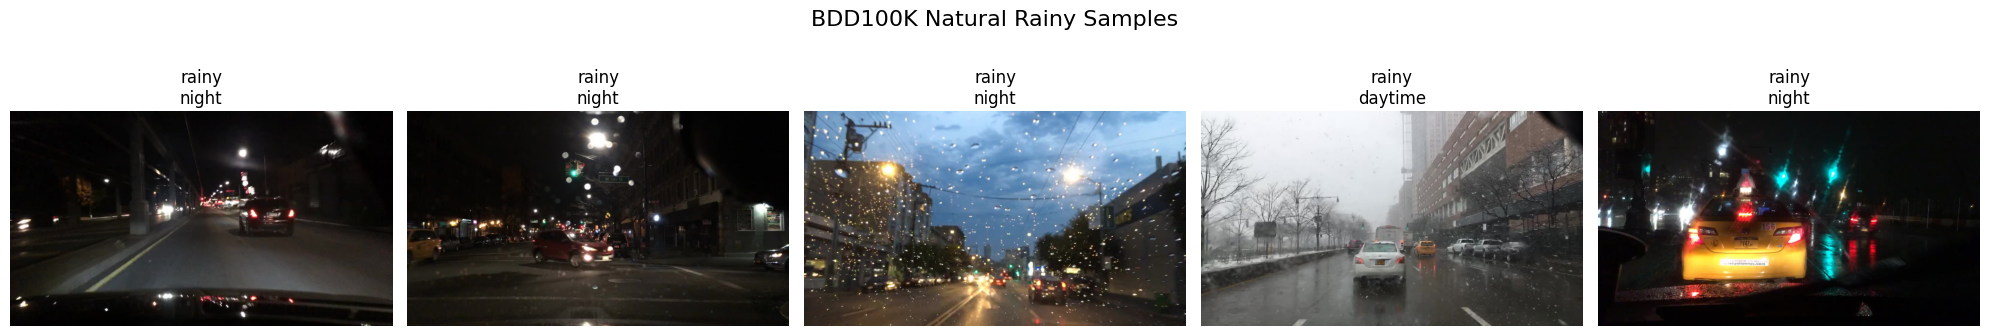


WEATHER: SNOWY
Available images: 5571


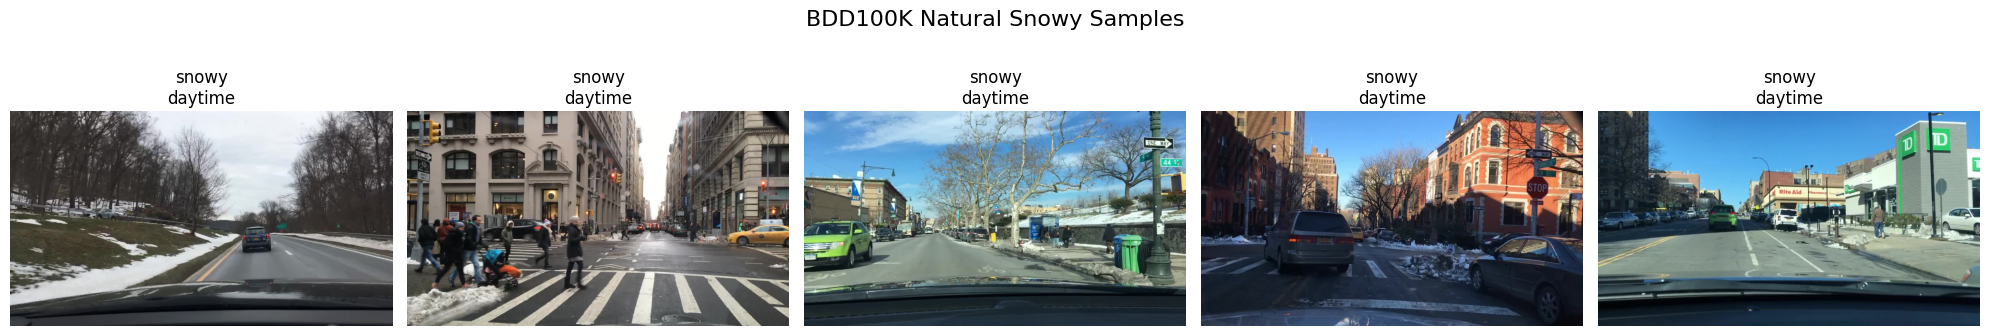


WEATHER: FOGGY
Available images: 130


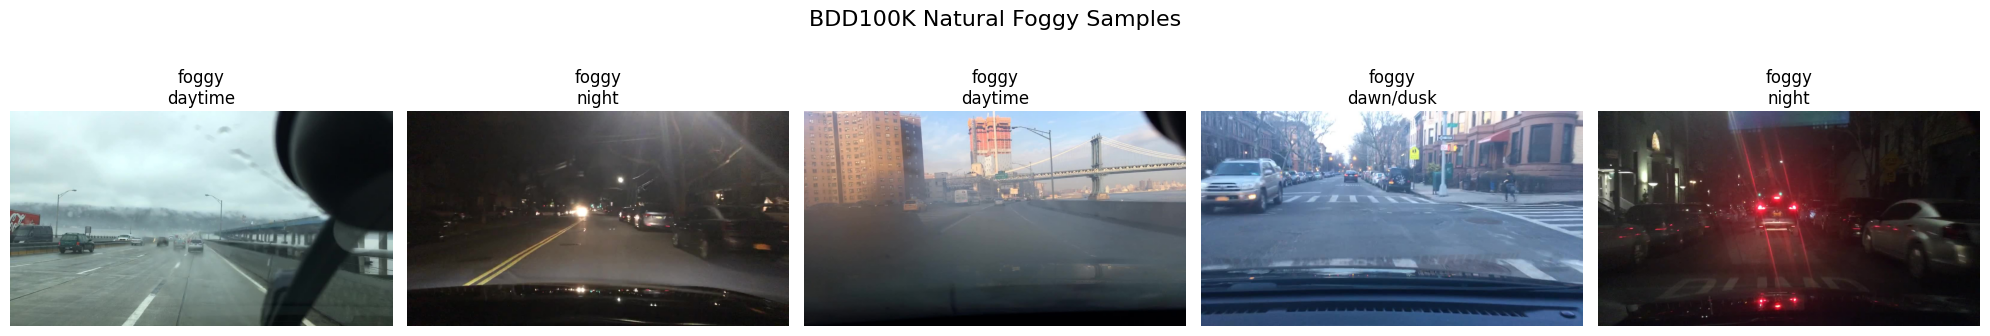

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import random

# ============================================================
# WEATHER LABEL VISUAL VALIDATION
# ============================================================

DATASET_ROOT = Path(
    r"E:\ML_Project\datasets\bdd100k_original_yolo"
)

METADATA_FILE = DATASET_ROOT / "bdd100k_metadata.csv"

df = pd.read_csv(METADATA_FILE)

random.seed(42)

WEATHER_TYPES = [
    "rainy",
    "snowy",
    "foggy"
]

N_SAMPLES = 5

for weather in WEATHER_TYPES:

    subset = df[
        (df["weather"] == weather) &
        (df["split"] == "train")
    ]

    print("\n" + "=" * 70)
    print(f"WEATHER: {weather.upper()}")
    print("=" * 70)

    print("Available images:", len(subset))

    if len(subset) == 0:
        print("No images found.")
        continue

    n = min(N_SAMPLES, len(subset))

    samples = subset.sample(
        n=n,
        random_state=42
    )

    fig, axes = plt.subplots(
        1,
        n,
        figsize=(20, 4)
    )

    if n == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, samples.iterrows()):

        image_name = row["image_name"]

        image_path = (
            DATASET_ROOT /
            row["split"] /
            "images" /
            f"{image_name}.jpg"
        )

        if not image_path.exists():
            ax.set_title("Image not found")
            ax.axis("off")
            continue

        image = Image.open(image_path)

        ax.imshow(image)
        ax.set_title(
            f"{weather}\n"
            f"{row['timeofday']}"
        )
        ax.axis("off")

    plt.suptitle(
        f"BDD100K Natural {weather.capitalize()} Samples",
        fontsize=16
    )

    plt.tight_layout()
    plt.show()